In [147]:
import nt2

data = nt2.Data(path="/travail/xgong/shock/output/shock_amano09/")
data

Fields:
  - coordinates: Cartesian
  - data axes: t, y, x
    - dt: 2.47e-02
    - t: 0.02 -> 1000.12 [6]
    - y: 0.03 -> 12.78 [256]
    - x: 0.03 -> 204.78 [4096]
    - s: 1 -> 40411 [6]
    - x_min: 0.00 -> 204.75 [4096]
    - x_max: 0.05 -> 204.80 [4096]
    - y_min: 0.00 -> 12.75 [256]
    - y_max: 0.05 -> 12.80 [256]
  - quantities: Bx, By, Bz, Ex, Ey, Ez, 
                Jx, Jy, Jz, N_1, N_2, Ttt_1, 
                Ttt_2, Ttx_1, Ttx_2, Tty_1, Tty_2, Ttz_1, 
                Ttz_2, Txx_1, Txx_2, Txy_1, Txy_2, Txz_1, 
                Txz_2, Tyy_1, Tyy_2, Tyz_1, Tyz_2, Tzz_1, 
                Tzz_2
  - total size: 1.6 GB

Particle species:
  - species: 1, 2
  - timesteps: 6
  - quantities: ux, uy, uz, w, x, y, 
                id, sp
  - total size: 993.8 MB


(500.0, 2000.0)

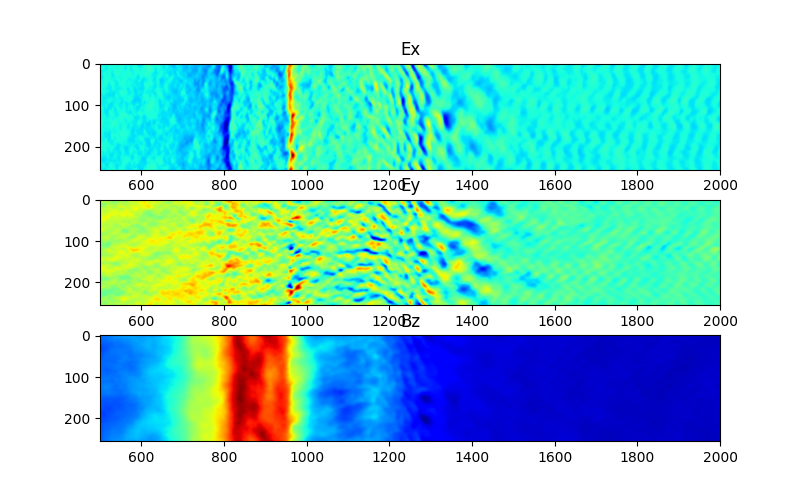

In [161]:
arr = data.fields#.sel(sp = 1000)
import numpy as np
# print(arr)
# arr = arr.load()#.load()

import matplotlib.pyplot as plt
a = -2
%matplotlib widget
# plt.plot(np.mean(arr['N'][6,:,:], 0))
fig, (ax1, ax2, ax3) = plt.subplots(3,figsize=(8,5))
ax1.imshow(arr['Ex'][a,:,:], cmap='jet')
ax2.imshow(arr['Ey'][a,:,:], cmap='jet')
ax3.imshow(arr['Bz'][a,:,:], cmap='jet')
ax1.set_title('Ex')
ax2.set_title('Ey')
ax3.set_title('Bz')
ax1.set_xlim(500,2000)
ax2.set_xlim(500,2000)
ax3.set_xlim(500,2000)
# plt.ylim(0,4)
# plt.hist2d(arr)

In [149]:
t0 = 1000
prtls = data.particles.sel(t=t0, method="nearest",sp=2)
prtlse = data.particles.sel(t=t0, method="nearest",sp=1)

In [150]:
uxi = prtls.load()['ux'].to_numpy()
uyi = prtls.load()['uy'].to_numpy()
uzi = prtls.load()['uz'].to_numpy()
xi = prtls.load()['x'].to_numpy()
uxe = prtlse.load()['ux'].to_numpy()
uye = prtlse.load()['uy'].to_numpy()
uze = prtlse.load()['uz'].to_numpy()
xe = prtlse.load()['x'].to_numpy()

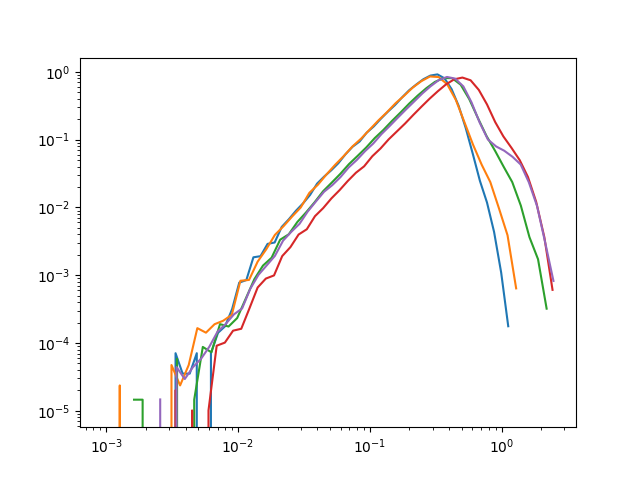

In [151]:

def plotspec(x1, x2):
    idse = np.where((xe < x2) & (xe > x1))[0]
    vmode = np.sqrt(uxe**2 + uye**2 + uze**2)[idse]
    # idsi = np.where((xi < 40) & (xi > 20))[0]
    # vmodi = np.sqrt(uxi**2 + uyi**2 + uzi**2)[idsi]
    bins = np.logspace(np.log10(vmode.min() + 1e-8), np.log10(vmode.max()), 50)

    img = np.histogram(vmode, bins=bins, density=True)
    x,y = (img[1][:-1], img[0][:])
    # plt.figure()
    plt.loglog(x,y*x)

plt.figure()
plotspec(20,30)
plotspec(30,40)
plotspec(40,50)
plotspec(50,60)
plotspec(60,70)

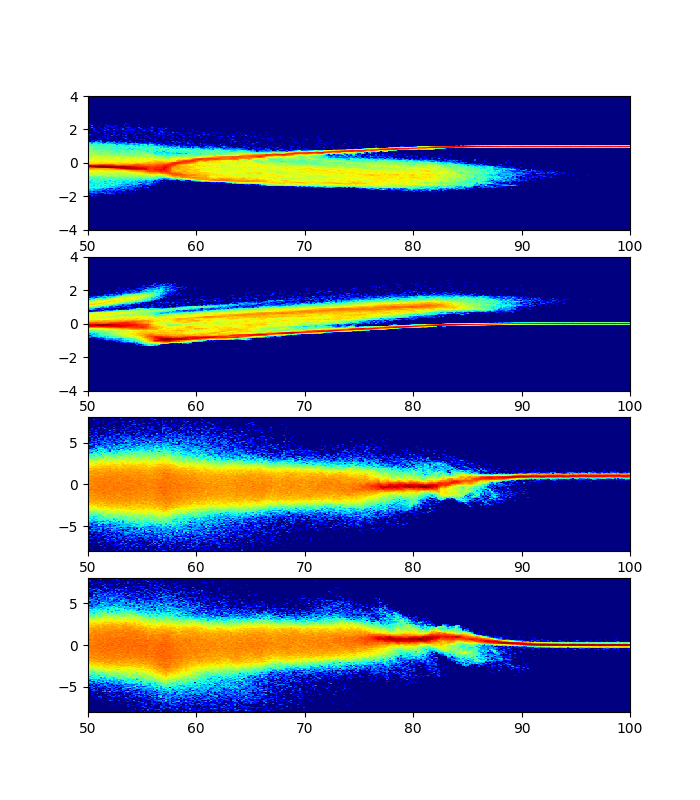

In [157]:
import matplotlib
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, figsize=(7,8))
# plt.hist2d(x,ux)
u0 = 0.2
xmin = 50
xmax = 100
numx, numy = 301, 201
cmap = matplotlib.cm.jet.copy()
cmap.set_bad(color=cmap(0))
bins_xi = np.linspace(xmin, xmax, numx)
bins_yi = np.linspace(-4,4,numy)
bins_xe = np.linspace(xmin, xmax, numx)
bins_ye = np.linspace(-8,8,numy)

img = ax1.hist2d(xi, -uxi/u0, bins = (bins_xi, bins_yi), norm=matplotlib.colors.LogNorm(), cmap=cmap)
img = ax2.hist2d(xi, -uyi/u0, bins = (bins_xi, bins_yi), norm=matplotlib.colors.LogNorm(), cmap=cmap)
img = ax3.hist2d(xe, -uxe/u0, bins = (bins_xe, bins_ye), norm=matplotlib.colors.LogNorm(), cmap=cmap)
img = ax4.hist2d(xe, -uye/u0, bins = (bins_xe, bins_ye), norm=matplotlib.colors.LogNorm(), cmap=cmap)